# Geostatistical Simulation of Antarctic Ice Thickness with GStatSim

This notebook demonstrates an end-to-end workflow for preparing and analyzing
IceBridge HiCARS radar ice thickness data for geostatistical simulation using
[GStatSim](https://gatorglaciology.github.io/gstatsimbook/intro.html).

## Overview

We use airborne radar data from NASA's Operation IceBridge — specifically the
HiCARS 1 and HiCARS 2 ice thickness products collected over Antarctica — as a
real-world example of working with large, irregular point datasets in a
geostatistical context.

**What this notebook covers:**
- Downloading HiCARS ice thickness granules from NSIDC via `earthaccess`
- Parsing the raw flight line text files and consolidating them into a single
  GeoParquet file for efficient storage and querying
- Reprojecting to Antarctic Polar Stereographic (EPSG:3031) for distance-based
  analysis
- Defining the study domain using a Wilkes Land shapefile
- Computing the experimental variogram for bed elevation using `gstatsim`
- Kriging

## Data

We use two IceBridge HiCARS products collected over Antarctica. Our study domain
is defined by a **Wilkes Land shapefile** — [Wilkes Land](https://en.wikipedia.org/wiki/Wilkes_Land)
is a large section of East Antarctica spanning roughly 100°E to 142°E.

| Product | Instrument | Granules | Landing Page |
|---------|-----------|----------|--------------|
| IR1HI2  | HiCARS 1  | 243      | [NSIDC](https://nsidc.org/data/ir1hi2/versions/1) |
| IR2HI2  | HiCARS 2  | 617      | [NSIDC](https://nsidc.org/data/ir2hi2/versions/1) |

## Environment Setup

Make sure you build and activate the conda environment if you want to run this in jupyter notebook. 

In [ ]:
from pathlib import Path
import tempfile

import earthaccess
import geopandas as gpd
import gstatsim as gs
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import pandas as pd
import pyogrio
import skgstat as skg
from skgstat import models
from sklearn.preprocessing import QuantileTransformer
from shapely import make_valid as shp_make_valid
import pyogrio
from shapely import make_valid as shp_make_valid
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from plot_utils import splot2D, mplot1, mplot2_std

## Authentication

You will need a free NASA Earthdata account to download data. If you don't have one,
register at [urs.earthdata.nasa.gov](https://urs.earthdata.nasa.gov).

`earthaccess.login()` will prompt for your credentials interactively. To avoid
entering them each time, you can persist them to a `.netrc` file:

```python
earthaccess.login(persist=True)  # only needs to be run once
```

In [2]:
earthaccess.login()

## Reprojection and Projected Coordinates

The raw files store positions as longitude/latitude in **WGS-84 (EPSG:4326)**, but
geostatistical methods like kriging require a **projected coordinate system** where
distances are in meters rather than degrees.

We reproject to **Antarctic Polar Stereographic (EPSG:3031)**, which is the standard
projection for Antarctic data and minimizes distortion at high southern latitudes.

We also write the projected coordinates as explicit `X` and `Y` columns alongside
the geometry. This is because `gstatsim` expects a plain DataFrame with numeric
`X` and `Y` columns in meters — it doesn't know how to read from a geometry column
directly.

In [3]:
def build_geoparquet(input_dir: str | Path, out_path: str | Path):
    """
    Batch-convert a directory of IceBridge HiCARS ice thickness text files
    to a single GeoParquet file.

    Reads all ``*.txt`` files in ``input_dir``, concatenates them, drops
    rows with missing coordinates, and constructs point geometries from
    LON/LAT (EPSG:4326). The data is reprojected to Antarctic polar
    stereographic (EPSG:3031) and projected ``X``/``Y`` coordinates are
    written as explicit columns alongside the geometry for direct use
    with gstatsim.

    Parameters
    ----------
    input_dir : str or Path
        Directory containing ``*_icethk.txt`` files (IR1HI2 and/or IR2HI2).
    out_path : str or Path
        Destination path for the output GeoParquet file.

    Returns
    -------
    gpd.GeoDataFrame
        GeoDataFrame in EPSG:3031 with all input columns plus ``X``, ``Y``,
        ``source_file``, and ``instrument``.
    """
    input_dir = Path(input_dir)
    files = sorted(input_dir.glob("*.txt"))
    print(f"Found {len(files)} files")

    chunks = [read_icethk(f) for f in files]
    df = pd.concat(chunks, ignore_index=True)
    print(f"Total rows (including NaN positions): {len(df):,}")

    df = df.dropna(subset=["LON", "LAT"])
    print(f"Rows with valid positions: {len(df):,}")

    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["LON"], df["LAT"]),
        crs="EPSG:4326",
    )

    gdf = gdf.to_crs("EPSG:3031")
    gdf["X"] = gdf.geometry.x
    gdf["Y"] = gdf.geometry.y

    gdf.to_parquet(out_path, compression="snappy")
    print(f"Written → {out_path}")
    return gdf

## Reading Individual Flight Line Files

Each granule downloaded from NSIDC is a single flight line — one `.txt` file per
aircraft transit. The files have a variable-length comment header (65 lines for
IR2HI2, 72 lines for IR1HI2) followed by space-delimited data.

`read_icethk` handles a single file: it detects the header length automatically
by scanning for the `Length_of_header` metadata field, parses the data block, and
tags each row with the source filename and instrument version (`HiCARS1` or `HiCARS2`)
for provenance tracking.

> **Note:** Rows with missing `LON`/`LAT` are retained at this stage — these occur
> at the start and end of flight lines where GPS lock was lost. They are dropped
> in `build_geoparquet` when we construct the point geometries.

In [4]:
def read_icethk(path: Path) -> pd.DataFrame:
    """
    Read a single IceBridge HiCARS ice thickness text file into a DataFrame.

    Parses the variable-length comment header by scanning for the
    ``Length_of_header`` metadata field, then reads the space-delimited
    data block. Missing values (``nan`` in the raw files) are preserved
    as ``NaN``. A ``source_file`` column and an ``instrument`` column
    (``HiCARS1`` or ``HiCARS2``, inferred from the filename prefix) are
    appended for provenance tracking.

    Parameters
    ----------
    path : Path
        Path to a ``*_icethk.txt`` file (IR1HI2 or IR2HI2 format).

    Returns
    -------
    pd.DataFrame
        DataFrame with columns: YEAR, DOY, SOD, LON, LAT, ICE_THICK,
        SRF_RNG, BED_ELEVATION, SURFACE_ELEVATION, BED_REFLECT,
        SRF_REFLECT, AIRCRAFT_ROLL, source_file, instrument.
        Rows with missing LON/LAT are retained at this stage.
    """
    with open(path) as f:
        for i, line in enumerate(f):
            if "Length_of_header:" in line:
                header_lines = int(line.split(":")[-1].strip().split()[0])
                break

    df = pd.read_csv(
        path,
        skiprows=header_lines,
        sep=r"\s+",
        names=COLUMNS,
        na_values="nan",
    )
    df["source_file"] = path.name
    df["instrument"] = "HiCARS1" if "IR1HI2" in path.name else "HiCARS2"
    return df

## Column Definitions

The HiCARS ice thickness files have a fixed 12-column schema documented in each
file's comment header. We define the column names here so they can be passed to
`read_icethk` at parse time — this lets us standardize naming across both IR1HI2
and IR2HI2 files, which use the same schema but slightly different header lengths.

Two names differ from the raw files:
- `THK` → `ICE_THICK`
- `PARTIAL_BED_REFLECT` → `BED_REFLECT`

In [5]:
COLUMNS = [
    "YEAR", "DOY", "SOD",
    "LON", "LAT",
    "ICE_THICK", "SRF_RNG", "BED_ELEVATION", "SURFACE_ELEVATION",
    "BED_REFLECT", "SRF_REFLECT", "AIRCRAFT_ROLL"
]

In [6]:
out_path = Path("../data/icethk_all.parquet").expanduser()
out_path.parent.mkdir(parents=True, exist_ok=True)

## Downloading IceBridge HiCARS Ice Thickness Data

We use [`earthaccess`](https://earthaccess.readthedocs.io/en/stable/) to search for and download 
granules from NASA Earthdata. `earthaccess` handles authentication and download in just a few lines 
of code — no manual file browsing required.

> **Finding a concept ID**  
> Each NASA Earthdata collection has a unique `concept_id` used to filter search results.  
> To find it, go to the dataset landing page (links below), click **"View data in Earthdata Search"**, 
> and copy the ID from the URL (e.g. `...?p=C3204979277-NSIDC_CPRD...`).  
> 
> Dataset landing pages:
> - [IR1HI2 — IceBridge HiCARS 1 L2 Ice Thickness](https://nsidc.org/data/ir1hi2/versions/1)
> - [IR2HI2 — IceBridge HiCARS 2 L2 Ice Thickness](https://nsidc.org/data/ir2hi2/versions/1)

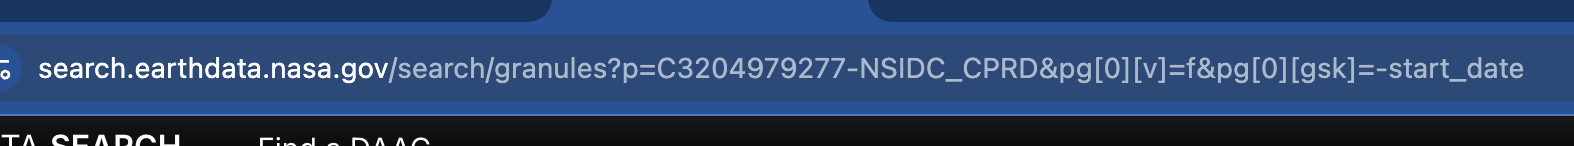

Full `search_data` parameter reference: [earthaccess docs](https://earthaccess.readthedocs.io/en/stable/api/#earthaccess.api.search_data)

## Download and Convert

This cell downloads 860 granules (~several GB) to a temporary directory and converts
them to a single GeoParquet. **This will take a while** depending
on your connection. The temp directory is cleaned up automatically after the parquet is written.

In [7]:
with tempfile.TemporaryDirectory() as tmpdir:
    for concept_id in ["C3204979277-NSIDC_CPRD", "C3204982997-NSIDC_CPRD"]:
        results = earthaccess.search_data(concept_id=concept_id)
        print(f"{concept_id}: {len(results)} granules")
        earthaccess.download(results, local_path=tmpdir)
        
    gdf = build_geoparquet(tmpdir, out_path)

C3204979277-NSIDC_CPRD: 243 granules


QUEUEING TASKS | :   0%|          | 0/243 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/243 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/243 [00:00<?, ?it/s]

C3204982997-NSIDC_CPRD: 617 granules


QUEUEING TASKS | :   0%|          | 0/617 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/617 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/617 [00:00<?, ?it/s]

Found 860 files
Total rows (including NaN positions): 9,700,516
Rows with valid positions: 9,372,683
Written → ../data/icethk_all.parquet


## Load and plot data
Load in bed topography measurements from sample area. 

A few rows of the data are previewed using `.head()`


In [8]:
datafile_path = Path("../data/icethk_all.parquet").expanduser()

gdf = gpd.read_parquet(datafile_path)

gdf.head()

,YEAR,DOY,SOD,LON,LAT,ICE_THICK,SRF_RNG,BED_ELEVATION,SURFACE_ELEVATION,BED_REFLECT,SRF_REFLECT,AIRCRAFT_ROLL,source_file,instrument,geometry,X,Y
531,2009,2,33057.5535,161.096539,-80.058225,532.63,1458.61,-520.62,-1458.61,-50.00,-21.90,11.11,IR1HI2_2009002_ICP1_JKB1a_F05T02a_icethk.txt,HiCARS1,POINT (350801.917 -1024406.626),350801.916733,-1.024407e+06
532,2009,2,33057.8034,161.097043,-80.058075,532.42,1458.25,-520.06,12.36,-48.79,-17.63,11.09,IR1HI2_2009002_ICP1_JKB1a_F05T02a_icethk.txt,HiCARS1,POINT (350798.224 -1024425.242),350798.223863,-1.024425e+06
533,2009,2,33058.0535,161.097547,-80.057925,NaN,1460.26,NaN,10.35,NaN,-16.40,11.08,IR1HI2_2009002_ICP1_JKB1a_F05T02a_icethk.txt,HiCARS1,POINT (350794.531 -1024443.859),350794.530694,-1.024444e+06
534,2009,2,33058.3032,161.098051,-80.057774,NaN,1464.00,NaN,6.60,NaN,-19.77,10.98,IR1HI2_2009002_ICP1_JKB1a_F05T02a_icethk.txt,HiCARS1,POINT (350790.873 -1024462.579),350790.872679,-1.024463e+06
535,2009,2,33058.5532,161.098556,-80.057624,NaN,1459.10,NaN,11.50,NaN,-14.17,10.64,IR1HI2_2009002_ICP1_JKB1a_F05T02a_icethk.txt,HiCARS1,POINT (350787.161 -1024481.202),350787.161030,-1.024481e+06


### Naming conventions

Throughout this notebook we use a consistent set of DataFrame names:

- **`gdf`** — the full GeoDataFrame (all columns, all rows)
- **`df`** — a lightweight copy with only the columns needed for analysis (`X`, `Y`, and the target field)
- **`df_sample`** — a random 1 % subsample of `df`, used for variogram fitting and exploratory plots
- **`df_grid`** — the data after gridding to the target simulation resolution

# Select the field to plot

In [9]:
field = 'BED_REFLECT'

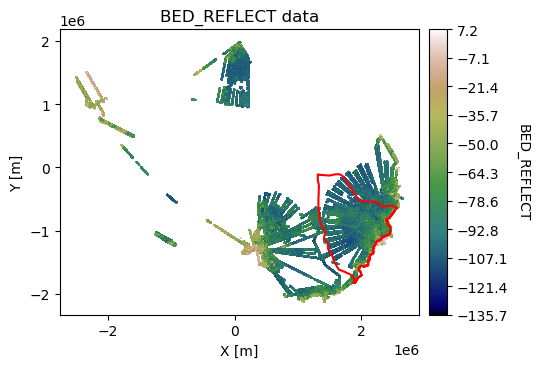

In [10]:
# plot data with WilkesLand boundary overlay

# Read shapefile — force_2d and on_invalid="fix" to handle unclosed rings
wilkes = pyogrio.read_dataframe("../data/WilkesLand/WilkesLand.shp", force_2d=True, on_invalid="fix")
wilkes["geometry"] = wilkes.geometry.apply(shp_make_valid)
wilkes = wilkes.set_crs("EPSG:3031").to_crs(gdf.crs)

vmin = gdf[field].min()
vmax = gdf[field].max()

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.scatter(gdf['X'], gdf['Y'], c=gdf[field], vmin=vmin, vmax=vmax,
                marker='.', s=0.5, cmap='gist_earth')
wilkes.boundary.plot(ax=ax, color='red', linewidth=1.5)
plt.title(f'{field} data')
plt.xlabel('X [m]'); plt.ylabel('Y [m]')
plt.locator_params(nbins=5)
plt.axis('scaled')

# make colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.1)
cbar = plt.colorbar(im, ticks=np.linspace(vmin, vmax, 11), cax=cax)
cbar.set_label(field, rotation=270, labelpad=15)
plt.show()

In [12]:
# Clip data to WilkesLand boundary (wilkes already loaded and reprojected above)
gdf = gpd.clip(gdf, wilkes)
print(f"Points after clipping: {len(gdf)}")

Points after clipping: 3539604


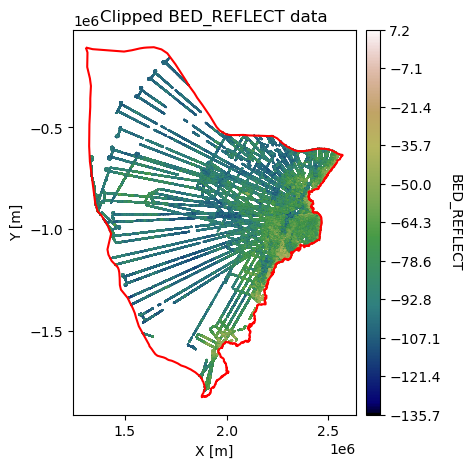

In [13]:
# Plot the clipped data
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.scatter(gdf['X'], gdf['Y'], c=gdf[field], vmin=vmin, vmax=vmax,
                marker='.', s=0.5, cmap='gist_earth')
wilkes.boundary.plot(ax=ax, color='red', linewidth=1.5)
plt.title(f'Clipped {field} data')
plt.xlabel('X [m]'); plt.ylabel('Y [m]')
plt.locator_params(nbins=5)
plt.axis('scaled')

# make colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.1)
cbar = plt.colorbar(im, ticks=np.linspace(vmin, vmax, 11), cax=cax)
cbar.set_label(field, rotation=270, labelpad=15)
plt.show()

In [14]:
df = gdf[['X', 'Y', field]].copy()
df.head()

,X,Y,BED_REFLECT
3257032,1.888603e+06,-1.794413e+06,NaN
3257031,1.888621e+06,-1.794400e+06,NaN
3257030,1.888640e+06,-1.794386e+06,NaN
3257029,1.888658e+06,-1.794373e+06,NaN
3257028,1.888676e+06,-1.794359e+06,-91.27


Next we downsample the large data set in order to quickly calculate an experimental variogram.

Subsampled 35396 points from 3539604


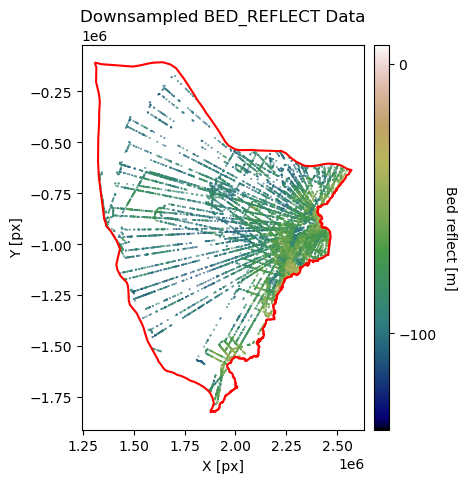

In [15]:
# Randomly downsample to x % of the dataset
df_sample = df.sample(frac=0.01, random_state=42)
print(f"Subsampled {len(df_sample)} points from {len(df)}")

# plot downsampled data
fig = plt.figure(figsize = (5,5))
ax = plt.gca()
im = ax.scatter(df_sample['X'], df_sample['Y'], c=df_sample['BED_REFLECT'], vmin=vmin, vmax=vmax,
                marker='.', s=0.5, cmap='gist_earth')
wilkes.boundary.plot(ax=ax, color='red', linewidth=1.5)
plt.title(f'Downsampled {field} Data')
plt.xlabel('X [px]'); plt.ylabel('Y [px]')

# make color bar
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.1)
cbar = plt.colorbar(im, ticks=np.linspace(-400, 600, 11), cax=cax)
cbar.set_label("Bed reflect [m]", rotation=270, labelpad=15)
plt.show()

## Compute normal score transformation
Many geostatistical methods require Gaussian assumptions, so we need to perform a normal score transformation to convert to a standard Gaussian distribution (mean = 0, standard deviaton = 1, Gaussian shape). After performing a geostatistical analysis such as kriging, the data is back-transformed to it's original distribution.

In [16]:
# normal score transformation
data = df_sample['BED_REFLECT'].values.reshape(-1,1)
nst_trans = QuantileTransformer(n_quantiles=500, output_distribution='normal').fit(data)
df_sample['BED_REFLECT'] = nst_trans.transform(data) 

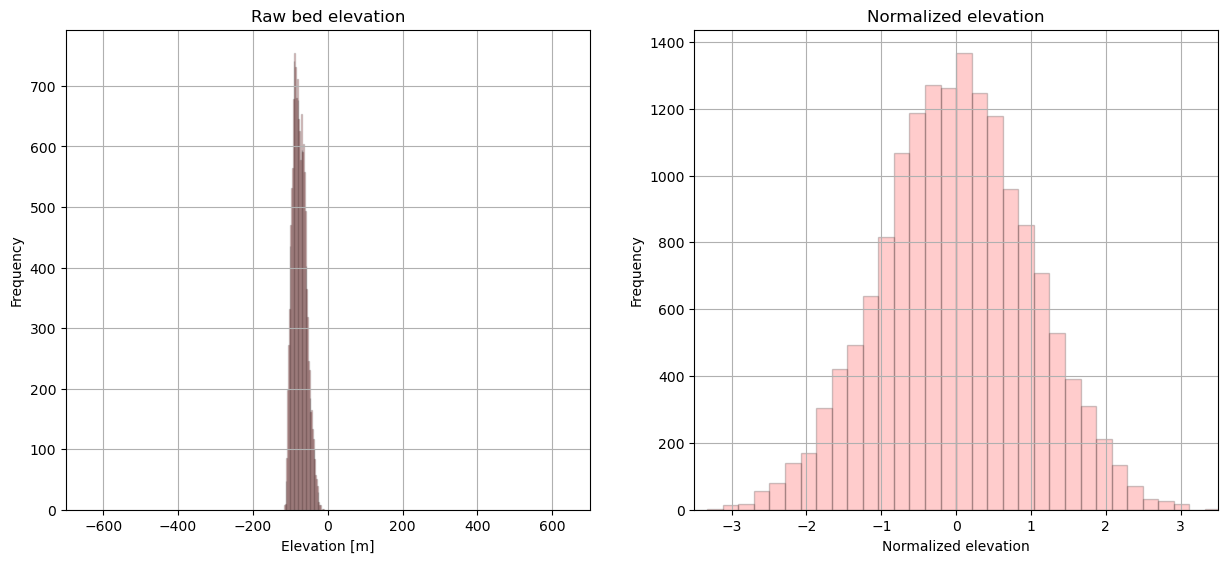

In [17]:
# plot original bed histogram
plt.subplot(121)
plt.hist(data, facecolor='red', bins=50, alpha=0.2, edgecolor='black')
plt.xlim([-700,700]); 
plt.xlabel('Elevation [m]'); plt.ylabel('Frequency'); plt.title('Raw bed elevation')
plt.grid(True)

# plot normal score bed histogram (with weights)
plt.subplot(122)
plt.hist(df_sample['BED_REFLECT'], facecolor='red', bins=50, alpha=0.2, edgecolor='black')
plt.xlim([-3.5,3.5]); 
plt.xlabel('Normalized elevation'); plt.ylabel('Frequency'); plt.title('Normalized elevation')
plt.grid(True)
plt.subplots_adjust(left=0.0, bottom=0.0, right=1.8, top=1.0, wspace=0.2, hspace=0.3)
plt.show()

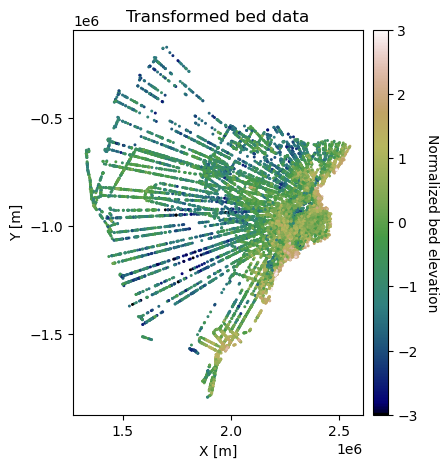

In [18]:
# plot transformed data
fig = plt.figure(figsize = (5,5))
ax = plt.gca()
im = ax.scatter(df_sample['X'], df_sample['Y'], c=df_sample['BED_REFLECT'], vmin=-3, vmax=3, 
                     marker='.', s=5, cmap='gist_earth')
plt.title('Transformed bed data')
plt.xlabel('X [m]'); plt.ylabel('Y [m]')
plt.locator_params(nbins=5)
plt.axis('scaled')

# make colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.1)
cbar = plt.colorbar(im, ticks=np.linspace(-3, 3, 7), cax=cax)
cbar.set_label("Normalized bed elevation", rotation=270, labelpad=15)
plt.show()

# Variogram Model  


Here we fit a variogram model to the experimental variogram calculated in the Experimental_Variogram example. Why fit a parametric variogram model to the experimental variogram? First of all, we need a way to interpolate variance estimates to all lag distances. Second, a variogram must satisfy certain mathematical properties in order to be used in kriging and stochastic simulation. This is covered in the Simple_Kriging.ipynb notebook.

The parameters of a variogram model are the nugget, sill, and range. The nugget or y-intercept represents small scale variability. Some of the nugget effect could be attributed to measurement error. The range is the lag distance where the variogram levels off. This means that two points separated by a lag distance greater than or equal to the range are not spatially correlated. The sill is the maximum variability between two points. When working with data that has been transformed to a standard Gaussian distribution, the sill is approximately 1. 


:::{figure-md} markdown-fig
<img src="./Images/variogram.png" class="bg-primary mb-1" width="500px">

Variogram schematic
:::

We use the SciKit-GStat package to model our variograms (see https://scikit-gstat.readthedocs.io/en/latest/ for more details).

In [19]:
wilkes = pyogrio.read_dataframe("../data/WilkesLand/WilkesLand.shp", force_2d=True, on_invalid="fix")
wilkes["geometry"] = wilkes.geometry.apply(shp_make_valid)
wilkes = wilkes.set_crs("EPSG:3031").to_crs(gdf.crs)

In [20]:
#clipping to wilkesland
# Clip data to WilkesLand boundary (wilkes already loaded and reprojected above)
gdf = gpd.clip(gdf, wilkes)
print(f"Points after clipping: {len(gdf)}")

Points after clipping: 3539604


In [21]:
gdf=gdf.dropna()
print(f"Points after clipping: {len(gdf)}")

Points after clipping: 1590497


In [22]:
#ok now randomly sampling 1% of my data to form the variogram which speeds it up for the purpose of this example

df_sample = gdf.sample(frac=0.01, random_state=42)

In [23]:

# normal score transformation
data = df_sample['BED_REFLECT'].values.reshape(-1,1)
nst_trans = QuantileTransformer(n_quantiles=500, output_distribution="normal").fit(data)
df_sample['BED_REFLECT'] = nst_trans.transform(data) 

# compute experimental (isotropic) variogram
coords = df_sample[['X','Y']].values
values = df_sample['BED_REFLECT']
print(values)
maxlag = 50000          # maximum range distance
n_lags = 70             # num of bins

# compute variogram
V1 = skg.Variogram(coords, values, bin_func='even', n_lags=n_lags, 
                   maxlag=maxlag, normalize=False)

# extract variogram values
xdata = V1.bins
ydata = V1.experimental


4343710    2.578137
2528316   -2.723210
8707534    1.142966
2871308   -0.335204
4349051   -0.765628
             ...   
9261531    0.318243
5090314    0.072543
5489114    0.138076
1256731   -0.562247
393025    -1.848227
Name: BED_REFLECT, Length: 15905, dtype: float64


In [24]:
# use exponential variogram model
V1.model = 'matern' 
V1.parameters

[np.float64(49999.99412044034),
 np.float64(0.5041620231447657),
 np.float64(0.3346303597601832),
 0]

In [25]:
# set variogram parameters
vrange = V1.parameters[0]
vsill = V1.parameters[1]
vnugget = V1.parameters[2]

# evaluate models
xi = np.linspace(0, xdata[-1], 1000) 
y_exp = [models.matern(h, vrange, vsill, vnugget) for h in xi]

## Grid and transform data. Get variogram parameters
Grid data to the desired simulation resolution. This is important because the resolution of the data affects the spatial statistics. We recommend gridding the data to the resolution at which you will be performing the interpolation.

In [26]:

# --- Fit variogram on 1% sample (fast) ---
df_sample = gdf.sample(frac=0.01, random_state=42)
sample_data = df_sample['BED_REFLECT'].values.reshape(-1,1)
nst_sample = QuantileTransformer(n_quantiles=500, output_distribution="normal").fit(sample_data)
df_sample['NBED_REFLECT'] = nst_sample.transform(sample_data)

coords_sample = df_sample[['X','Y']].values
values_sample = df_sample['NBED_REFLECT']

maxlag = 50000
n_lags = 70

V1 = skg.Variogram(coords_sample, values_sample, bin_func='even', n_lags=n_lags, 
                   maxlag=maxlag, normalize=False)
V1.model = 'matern'
print("Variogram parameters (range, sill, smoothness, nugget):", V1.parameters)

# --- Grid full dataset for kriging ---
res = 10000 #10km grid
df_grid, grid_matrix, rows, cols = gs.Gridding.grid_data(gdf, 'X', 'Y', 'BED_REFLECT', res)
df_grid = df_grid[df_grid["Z"].isnull() == False]
df_grid = df_grid.rename(columns = {"Z": "BED_REFLECT"})

# normal score transformation on full gridded data
data = df_grid['BED_REFLECT'].values.reshape(-1,1)
nst_trans = QuantileTransformer(n_quantiles=500, output_distribution="normal").fit(data)
df_grid['NBED_REFLECT'] = nst_trans.transform(data)

print(f"Gridded points for kriging: {len(df_grid)}")

Variogram parameters (range, sill, smoothness, nugget): [np.float64(49999.99412044164), np.float64(0.4934954030656008), np.float64(0.3389927391320899), 0]
Gridded points for kriging: 5101


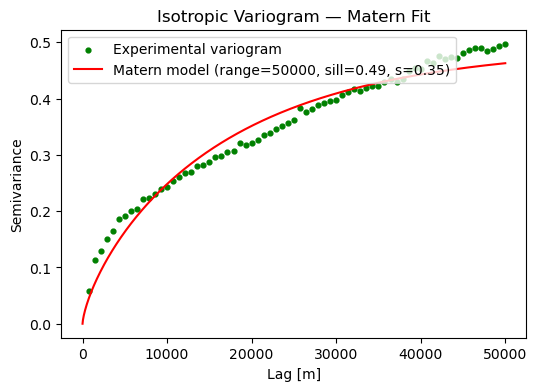

In [27]:

# plot experimental variogram with fitted matern model
vrange = V1.parameters[0]
vsill = V1.parameters[1]
vsmooth = 0.35 # V1.parameters[2]
vnugget = V1.parameters[3]

xdata = V1.bins
ydata = V1.experimental

xi = np.linspace(0, xdata[-1], 1000)
y_model = [models.matern(h, vrange, vsill, vsmooth, vnugget) for h in xi]

plt.figure(figsize=(6,4))
plt.scatter(xdata, ydata, s=12, c='g', label='Experimental variogram')
plt.plot(xi, y_model, '-r', label=f'Matern model (range={vrange:.0f}, sill={vsill:.2f}, s={vsmooth:.2f})')
plt.title('Isotropic Variogram — Matern Fit')
plt.xlabel('Lag [m]'); plt.ylabel('Semivariance')
plt.legend(loc='upper left')
plt.show()

For anisotropic variograms, the variogram should be modeled in the major (smoothest) and minor (roughest) directions, which are typicaly orthogonal to each other.

Now that the variogram is modeled, we can use this information to perform interpolations.

Download the tutorial {Download}`here<./2_Variogram_model.ipynb>`.

In [28]:
# define coordinate grid based on full shapefile extent (not just data extent)
wilkes_bounds = wilkes.total_bounds  # [xmin, ymin, xmax, ymax]
xmin = wilkes_bounds[0]; xmax = wilkes_bounds[2]
ymin = wilkes_bounds[1]; ymax = wilkes_bounds[3]

Pred_grid_xy, pred_cols, pred_rows = gs.Gridding.make_grid(xmin, xmax, ymin, ymax, res)
# use prediction grid rows/cols for plotting (may differ from grid_data's rows/cols)
rows = pred_rows
cols = pred_cols
print(f"Prediction grid: {len(Pred_grid_xy)} points, rows={rows}, cols={cols}")

# create mask for cells inside the Wilkes basin shapefile
from shapely.geometry import Point
pred_gdf = gpd.GeoDataFrame(
    geometry=[Point(x, y) for x, y in Pred_grid_xy],
    crs=gdf.crs
)
inside_mask = pred_gdf.within(wilkes.union_all())
print(f"Points inside Wilkes basin: {inside_mask.sum()} of {len(Pred_grid_xy)}")

Prediction grid: 21844 points, rows=172, cols=127
Points inside Wilkes basin: 11784 of 21844


## Simple kriging
Simple kriging assumes that the mean is stationary and known. The data is treated as a residual from the mean, which is computed as the average of conditioning points. Sometimes this is a good assumption, but in some cases it is not. We will apply it here to see what happens.

In [29]:
# set variogram parameters (matern: range, sill, smoothness, nugget)
azimuth = 0
nugget = V1.parameters[3]

# the major and minor ranges are the same in this example because it is isotropic
major_range = V1.parameters[0]
minor_range = V1.parameters[0]
sill = V1.parameters[1]
s = V1.parameters[2]  # matern smoothness parameter

# save variogram parameters as a list
vario = [azimuth, nugget, major_range, minor_range, sill, 'matern', s]

k = 50         # number of neighboring data points used to estimate a given point
rad = 1000000    # search radius (m)

# est_SK is the estimate and var_SK is the variance
est_SK, var_SK = gs.Interpolation.skrige(Pred_grid_xy, df_grid, 'X', 'Y', 'NBED_REFLECT', k, vario, rad)

100%|██████████| 21844/21844 [01:13<00:00, 297.61it/s]



Although the SciKit-GStat package fits a sill parameter, we prefer to use a sill of 1 because it makes the covariance zero for measurements with lag distances greater than the range, which tends to make simulation algorithms run better. However, you can still substitute in a different sill value if you wish.

Here, k is the number of conditioning nodes used to estimate a grid cell. This means that each estimate will be informed the by k nearby measurements within a specified search radius. The search radius should be at least as large as the largest measurement gap. If you're getting errors, it is usually because the radius is too small. Generally speaking, increasing the search radius and number of conditioning nodes improves the simulation quality.

The simulation is applied to the transformed data, so a reverse normal score transformation must be applied to recover the original distribution.

In [30]:

# reverse normal score transformation

var_SK[var_SK < 0] = 0      # make sure variances are non-negative
std_SK = np.sqrt(var_SK)    # convert to standard deviation before back transforming

# reshape
est = est_SK.reshape(-1,1)
std = std_SK.reshape(-1,1)

# back transformation
spred_trans = nst_trans.inverse_transform(est)
sstd_trans = nst_trans.inverse_transform(std)
sstd_trans = sstd_trans - np.min(sstd_trans)

# mask values outside Wilkes basin
spred_trans[~inside_mask.values] = np.nan
sstd_trans[~inside_mask.values] = np.nan


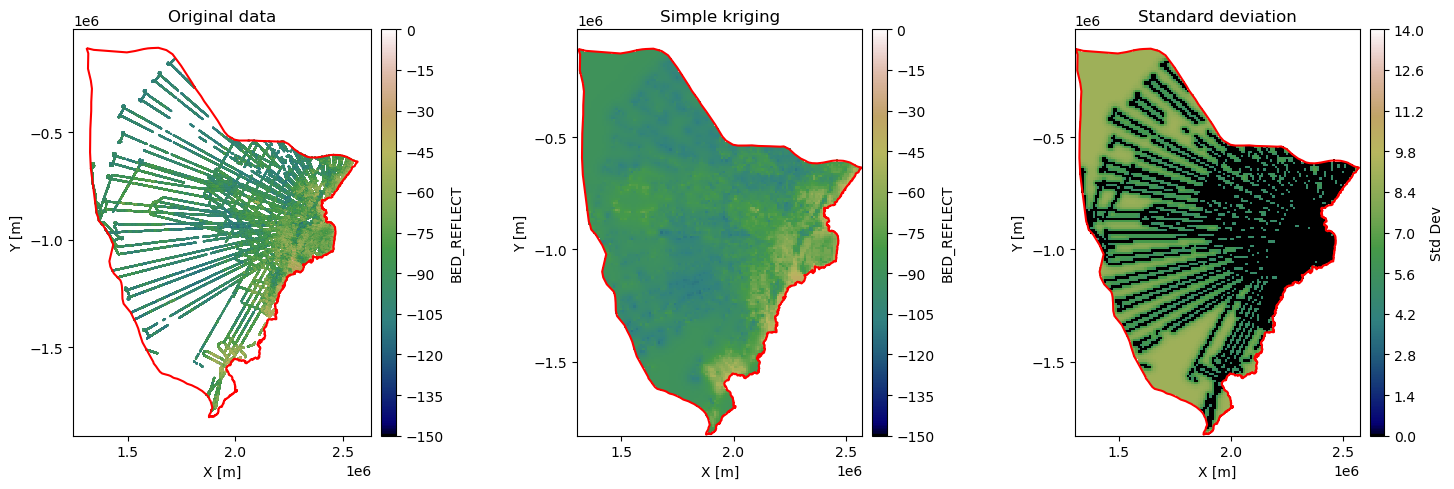

In [34]:
# plot includes original data, simple kriging, and standard deviation (3 panels)
from mpl_toolkits.axes_grid1 import make_axes_locatable

x_mat = Pred_grid_xy[:,0].reshape((rows, cols))
y_mat = Pred_grid_xy[:,1].reshape((rows, cols))
pred_mat = spred_trans.reshape((rows, cols))
std_mat = sstd_trans.reshape((rows, cols))

pred_vmin = -150; pred_vmax = 0
std_vmin = 0; std_vmax = 14

fig, [ax1, ax2, ax3] = plt.subplots(1, 3, figsize=(15, 5))

# panel 1: original radar line data
im1 = ax1.scatter(gdf['X'], gdf['Y'], c=gdf['BED_REFLECT'], vmin=pred_vmin, vmax=pred_vmax,
                  marker='.', s=0.5, cmap='gist_earth')
wilkes.boundary.plot(ax=ax1, color='red', linewidth=1.5)
ax1.set_title('Original data')
ax1.set_xlabel('X [m]'); ax1.set_ylabel('Y [m]')
ax1.locator_params(nbins=5)
ax1.axis('scaled')
divider1 = make_axes_locatable(ax1)
cax1 = divider1.append_axes('right', size='5%', pad=0.1)
fig.colorbar(im1, ticks=np.linspace(pred_vmin, pred_vmax, 11), cax=cax1, label='BED_REFLECT')

# panel 2: simple kriging
im2 = ax2.pcolormesh(x_mat, y_mat, pred_mat, vmin=pred_vmin, vmax=pred_vmax, cmap='gist_earth')
wilkes.boundary.plot(ax=ax2, color='red', linewidth=1.5)
ax2.set_title('Simple kriging')
ax2.set_xlabel('X [m]'); ax2.set_ylabel('Y [m]')
ax2.locator_params(nbins=5)
ax2.axis('scaled')
divider2 = make_axes_locatable(ax2)
cax2 = divider2.append_axes('right', size='5%', pad=0.1)
fig.colorbar(im2, ticks=np.linspace(pred_vmin, pred_vmax, 11), cax=cax2, label='BED_REFLECT')

# panel 3: standard deviation
im3 = ax3.pcolormesh(x_mat, y_mat, std_mat, vmin=std_vmin, vmax=std_vmax, cmap='gist_earth')
wilkes.boundary.plot(ax=ax3, color='red', linewidth=1.5)
ax3.set_title('Standard deviation')
ax3.set_xlabel('X [m]'); ax3.set_ylabel('Y [m]')
ax3.locator_params(nbins=5)
ax3.axis('scaled')
divider3 = make_axes_locatable(ax3)
cax3 = divider3.append_axes('right', size='5%', pad=0.1)
fig.colorbar(im3, ticks=np.linspace(std_vmin, std_vmax, 11), cax=cax3, label='Std Dev')

plt.tight_layout()
plt.show()


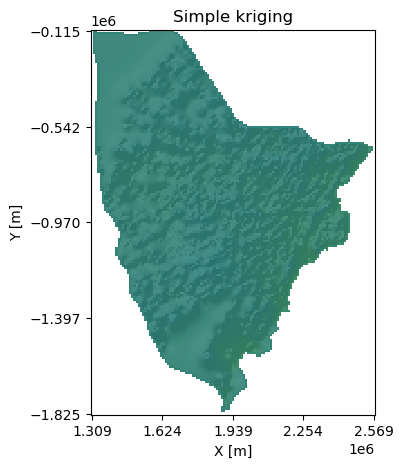

In [35]:
# plot hillshade for visualizing
mplot1(Pred_grid_xy, spred_trans, rows, cols, title='Simple kriging', hillshade=True)



The downside of simple kriging is that it assumes that all the data points are a residual from a constant mean across the area. This could give us a biased estimate, especially if there are differences in data density at different elevations. Let's try ordinary kriging, where the mean is unknown.



## Ordinary kriging
Ordinary kriging (OK) uses a locally varying mean. This makes OK more robust to trends.

In [ ]:
k = 100
est_OK, var_OK = gs.Interpolation.okrige(Pred_grid_xy, df_grid, 'X', 'Y', 'NBED_REFLECT', k, vario, rad) # estimation and variance

# reverse normal score transformation
var_OK[var_OK < 0] = 0; # make sure variances are non-negative
std_OK = np.sqrt(var_OK) # convert to standard deviation (this should be done before back transforming!!!)

# reshape
est = est_OK.reshape(-1,1)
std = std_OK.reshape(-1,1)

# back transformation
pred_trans = nst_trans.inverse_transform(est)
std_trans = nst_trans.inverse_transform(std)
std_trans = std_trans - np.min(std_trans)

# mask values outside Wilkes basin
pred_trans[~inside_mask.values] = np.nan

 14%|█▎        | 2975/21844 [00:09<01:02, 302.00it/s]

In [ ]:
# plot simple kriging and standard deviation
mplot2_std(Pred_grid_xy, pred_trans, std_trans,
           rows, cols, title1='Ordinary kriging', title2='Standard deviation',
           vmin=-150, vmax=0, std_vmin=0, std_vmax=14,
           clabel='BED_REFLECT', std_clabel='Std Dev')

In [ ]:
# make hillshade for visualizing
mplot1(Pred_grid_xy, pred_trans, rows, cols, title='Ordinary kriging', hillshade=True)


Here, the righthand side of the ordinary kriging output is higher elevation than the simple kriging map. This is because ordinary kriging accounts for the large-scale trend of increasing elevation from left to right. However, there appear to be some artifacts in this region as well. This is because this area does not have many measurements, making it difficult to reliably estimate the local mean. This issue could be improved by increasing the search radius.

## Difference between simple kriging and ordinary kriging

In [ ]:

diff = spred_trans - pred_trans
mplot1(Pred_grid_xy, diff, rows, cols, title='Simple kriging minus ordinary kriging', 
       vmin=-80, vmax=20, clabel='Difference [m]')

The differences tend to be the most pronounced in areas that are not near conditioning points.

## Kriging roughness
You'll also notice that parts of kriging outputs look quite smooth. This is because kriging performs interpolations by averaging measurements. Let's compare the variograms of the data and the kriging results to see how they differ.

Notice that we're using the simple kriging values prior to back transfo.rmation because the experimental variogram was computed on normalized data.

In [ ]:

# compute simple kriging variogram
coords_s = Pred_grid_xy
values_s = est_SK

VS = skg.Variogram(coords_s, values_s, bin_func='even', n_lags=n_lags, 
                   maxlag=maxlag, normalize=False)

In [ ]:

# experimental variogram (from beginning of script)
xe = V1.bins
ye = V1.experimental

# simple kriging variogram
xs = VS.bins
ys = VS.experimental

plt.figure(figsize=(6,4))
plt.plot(xe,ye,'og', markersize=4, label='Bed data variogram')
plt.plot(xs,ys,'ob', markersize=4, label='Simple kriging variogram')
plt.title('Variogram comparison')
plt.xlabel('Lag [m]'); plt.ylabel('Semivariance')  
plt.legend(loc='upper left')
plt.show()


Download the tutorial {Download}here<./3_Simple_kriging_and_ordinary_kriging.ipynb>.